### This is a hands on code implementation of backpropagation used in neural networks. This is the file that contains the engine of the entire program.

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', _label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._label = _label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        product = Value(self.data * other.data, (self, other), '*')
        return product


# Create input values
a = Value(2.0, _label='a')
b = Value(-3.0, _label='b')
c = Value(10.0, _label='c')
f = Value(-2.0, _label='f')

# Forward pass
e = a * b
e._label = "e"

d = e + c
d._label = 'd'

L = d * f
L._label = 'L'

In [ ]:
from graphviz import Digraph


def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """Visualize the computation graph."""
    dot = Digraph(format='svg', graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # Create a rectangular node for each value
        dot.node(
            name=uid,
            label="{%s | data %.4f | grad %.4f}" % (n._label, n.data, n.grad),
            shape='record'
        )
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

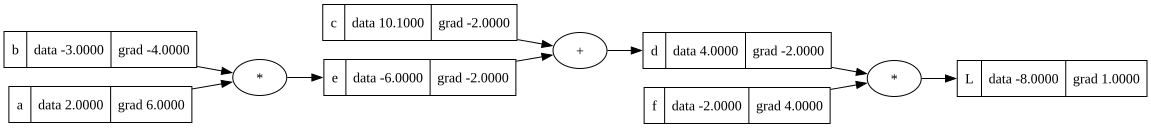

In [104]:
draw_dot(L)

In [ ]:
# Gradient descent step (nudge values in direction that reduces L)
learning_rate = 0.01

a.data += learning_rate * a.grad
b.data += learning_rate * b.grad
c.data += learning_rate * c.grad
f.data += learning_rate * f.grad

# Recompute forward pass
e = a * b
d = e + c
L = d * f

print(L.data)

-7.719656


## Backpropagation: Computing Gradients

Our computation graph: `L = (a * b + c) * f`

Expanded: `e = a * b`, `d = e + c`, `L = d * f`

| Node | Value | Gradient | Derivation |
|------|-------|----------|------------|
| **L** | -8 | 1.0 | $\frac{\partial L}{\partial L} = 1$ (base case) |
| **d** | 4 | -2.0 | $\frac{\partial L}{\partial d} = f = -2$ (since $L = d \cdot f$) |
| **f** | -2 | 4.0 | $\frac{\partial L}{\partial f} = d = 4$ (since $L = d \cdot f$) |
| **e** | -6 | -2.0 | $\frac{\partial L}{\partial e} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e} = -2 \cdot 1 = -2$ (since $d = e + c$) |
| **c** | 10 | -2.0 | $\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial c} = -2 \cdot 1 = -2$ (since $d = e + c$) |
| **a** | 2 | 6.0 | $\frac{\partial L}{\partial a} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial a} = -2 \cdot b = -2 \cdot (-3) = 6$ |
| **b** | -3 | -4.0 | $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial b} = -2 \cdot a = -2 \cdot 2 = -4$ |

### Key Rules:
- **Multiplication**: $\frac{\partial (x \cdot y)}{\partial x} = y$ and $\frac{\partial (x \cdot y)}{\partial y} = x$
- **Addition**: $\frac{\partial (x + y)}{\partial x} = 1$ and $\frac{\partial (x + y)}{\partial y} = 1$
- **Chain Rule**: Multiply local gradient by upstream gradient

## Step-by-Step Gradient Calculation

**Given:** $a=2$, $b=-3$, $c=10$, $f=-2$

**Forward Pass:**
- $e = a \times b = 2 \times (-3) = -6$
- $d = e + c = -6 + 10 = 4$
- $L = d \times f = 4 \times (-2) = -8$

---

**Backward Pass (Chain Rule):**

**Step 1:** $\frac{\partial L}{\partial L} = 1$ 

**Step 2:** $L = d \times f$
- $\frac{\partial L}{\partial d} = f = -2$ 
- $\frac{\partial L}{\partial f} = d = 4$ 

**Step 3:** $d = e + c$
- $\frac{\partial L}{\partial e} = \frac{\partial L}{\partial d} \times 1 = -2 \times 1 = -2$ ✓
- $\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d} \times 1 = -2 \times 1 = -2$ 

**Step 4:** $e = a \times b$
- $\frac{\partial L}{\partial a} = \frac{\partial L}{\partial e} \times b = -2 \times (-3) = 6$ 
- $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial e} \times a = -2 \times 2 = -4$ 

In [ ]:
# Manually set gradients (backpropagation)
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
a.grad = 6.0
b.grad = -4.0

### Lets perform backprop on a multilayer neural network.